In [ ]:
from google.colab import files
uploaded=files.upload()

Saving taxi_trip_pricing.csv to taxi_trip_pricing.csv


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("taxi_trip_pricing.csv")

# Create 5 bins for Trip_Price
price_bins = pd.cut(df['Trip_Price'], bins=5)

# Count the number of samples in each bin
price_distribution = price_bins.value_counts().sort_index()

# Calculate the percentage for each bin
price_percentage = (price_distribution / price_distribution.sum()) * 100

# Display results
print("Trip Price Distribution :\n")
print(pd.DataFrame({'Count': price_distribution, 'percentage': price_percentage}))

Trip Price Distribution :

                    Count  percentage
Trip_Price                           
(5.801, 71.31]        737   77.497371
(71.31, 136.494]      193   20.294427
(136.494, 201.677]      1    0.105152
(201.677, 266.86]       8    0.841220
(266.86, 332.044]      12    1.261830


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
num_cols = ['Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']

for col in num_cols:
    print(f"\nStatistics for {col}:")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Variance:", df[col].var())
    print("Standard Deviation:", df[col].std())


Statistics for Base_Fare:
Mean: 3.502989473684211
Median: 3.52
Variance: 0.7571817807109976
Standard Deviation: 0.8701619278680248

Statistics for Per_Km_Rate:
Mean: 1.2333157894736844
Median: 1.22
Variance: 0.1847416809938439
Standard Deviation: 0.4298158687087343

Statistics for Per_Minute_Rate:
Mean: 0.2929157894736842
Median: 0.29
Variance: 0.01336145760079862
Standard Deviation: 0.11559177133688461

Statistics for Trip_Duration_Minutes:
Mean: 62.11811578947369
Median: 61.86
Variance: 1033.9058553501193
Standard Deviation: 32.1544064686338

Statistics for Trip_Price:
Mean: 56.87477332571041
Median: 50.07450000000001
Variance: 1637.803947177839
Standard Deviation: 40.46979055020966


In [ ]:
cat_cols = ['Time_of_Day', 'Day_of_Week', 'Passenger_Count', 'Traffic_Conditions', 'Weather']

for col in cat_cols:
    freq = df[col].value_counts()
    percent = df[col].value_counts(normalize=True) * 100
    print(f"\n{col} Distribution:\n")
    print(pd.DataFrame({'Count': freq, 'Percentage': percent.round(2)}))



Time_of_Day Distribution:

             Count  Percentage
Time_of_Day                   
Afternoon      371       39.05
Morning        283       29.79
Evening        203       21.37
Night           93        9.79

Day_of_Week Distribution:

             Count  Percentage
Day_of_Week                   
Weekday        655       68.95
Weekend        295       31.05

Passenger_Count Distribution:

                 Count  Percentage
Passenger_Count                   
3.0                251       26.42
2.0                241       25.37
1.0                238       25.05
4.0                220       23.16

Traffic_Conditions Distribution:

                    Count  Percentage
Traffic_Conditions                   
Low                   397       41.79
Medium                371       39.05
High                  182       19.16

Weather Distribution:

         Count  Percentage
Weather                   
Clear      667       70.21
Rain       227       23.89
Snow        56        5.89


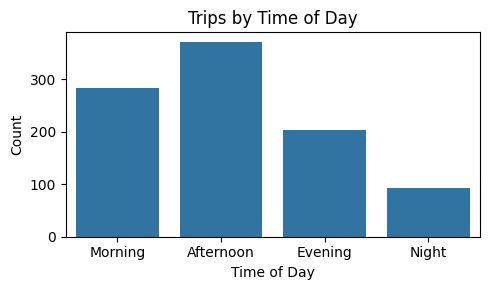

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(x='Time_of_Day', data=df)
plt.title('Trips by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


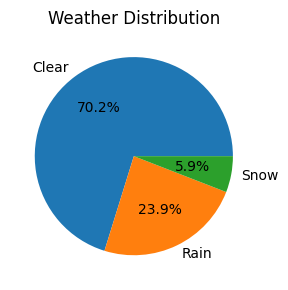

In [ ]:
plt.figure(figsize=(3,3))
df['Weather'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Weather Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()




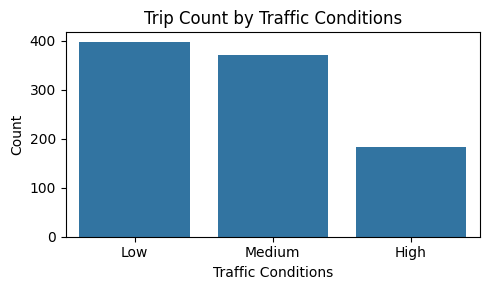

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(x='Traffic_Conditions', data=df, order=df['Traffic_Conditions'].value_counts().index)
plt.title("Trip Count by Traffic Conditions")
plt.xlabel("Traffic Conditions")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


<ipython-input-15-a0add1c38232>:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


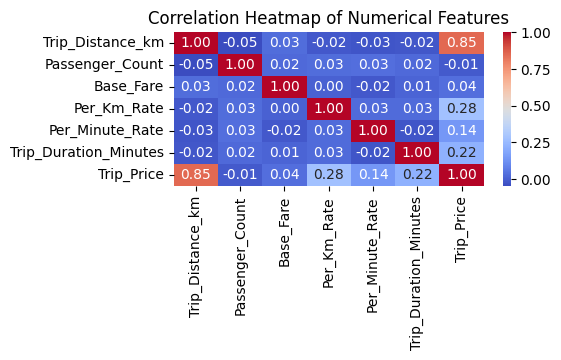

In [ ]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [16]:
missing_values = df.isnull().sum()

print(missing_values)

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64
